<a href="https://colab.research.google.com/github/amitpoa/Spam-Not-Spam-Classification-RNN-/blob/main/Spam_Not_Spam_Classification_(RNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports & Setup

In [ ]:
!pip install contractions
!pip install beautifulsoup4
!pip install scikit-learn
!pip install nltk
!pip install contractions
!pip install emoji

In [ ]:
import subprocess, sys

import contractions ### don't ---> do not (word processing)

from bs4 import BeautifulSoup

# ── Standard library imports ──────────────────────────────────
import re                          # Regular expressions for text cleaning
import string                      # Provides the list of punctuation characters
import unicodedata                 # Process unique numeric value
import pickle                      # Save/load Python objects (tokenizer) to disk
import numpy as np                 # Numerical operations on arrays
import pandas as pd                # Load and manipulate the CSV dataset
import os                          # File path handling
from collections import Counter    # Count occurrences of words
import emoji                       # Handle emojis in text
import matplotlib.pyplot as plt    # Plotting library
import seaborn as sns              # Advanced plotting
sns.set(style='whitegrid')         # Clean, white-grid style for plots

### English language dataset
import nltk
nltk.download('stopwords', quiet=True)   # Download English stopword list
nltk.download('punkt',     quiet=True)   # Download sentence/word tokenizer data
nltk.download('punkt_tab', quiet=True)   # Extra tokenizer data required by newer NLTK

from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

In [ ]:
import tensorflow as tf                                 # Import TensorFlow library for deep learning

from tensorflow.keras.models import Sequential, load_model    # Sequential: linear stack of layers; load_model: load saved models

from tensorflow.keras.layers import (Embedding, SimpleRNN, Dense, Dropout)  # Import neural network layers: Embedding( text vectorization), Bidirectional(LSTM wrapper), LSTM(vanilla LSTM), Dense(fully connected), Dropout(regularization)

from tensorflow.keras.preprocessing.text import Tokenizer     # Convert text words into integer sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences   # Make all sequences the same length by padding zeros

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # EarlyStopping: stop training when val loss stops improving; ModelCheckpoint: save best model during training

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


## 2. Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Spam Not Spam Classification RNN/spam.csv", encoding='latin1')
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df[['v1','v2']]
df.columns=['label','message']
df.head(5)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Data Cleaning and Preprocessing

In [ ]:
# Build the English stopword set once — reused for every review
STOP_WORDS = set(stopwords.words("english"))

def preprocess_text(text: str) -> str:
    """
    Apply all 8 cleaning steps to a single review string.
    Returns a cleaned string of meaningful words ready for the model.
    """

    # STEP 2 — Strip HTML tags  (e.g. <br />, <b>word</b>)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")

    # STEP 3 — Remove URLs  (e.g. https://imdb.com/title/...)
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # STEP 4 — Normalize non-ASCII characters
    text = text.replace("\u2019", "'").replace("\u2018", "'")  # curly apostrophes → straight (Curly: It’s a nice day. Straight: It's a nice day.)
    text = text.replace("\u201c", '"').replace("\u201d", '"')  # curly double quotes → straight (Curly: “Hello, world.” Straight: "Hello, world.")
    text = text.replace("\u2013", "-").replace("\u2014", "-")  # en-dash / em-dash → hyphen (With dashes: Pages 10–20—important section, With hyphen: Pages 10-20-important section)
    text = text.encode("ascii", errors="ignore").decode("ascii") # drop any remaining non-ASCII bytes

    # STEP 5 — Expand contractions  (don't → do not, I'm → I am, etc.)
    text = contractions.fix(text)

    # STEP 6 — Convert to lowercase  (Great → great, FILM → film)
    text = text.lower()

    # STEP 7 — Remove stopwords  (the, is, a, and, of … carry no sentiment)
    tokens = word_tokenize(text)                          # Split text into a list of words
    tokens = [w for w in tokens if w not in STOP_WORDS]  # Keep only meaningful words

    # STEP 8 - Convert emojis to text (e.g., "😊" to ":smiling_face_with_smiling_eyes:")
    text = emoji.demojize(text)

    # Remove punctuation now so tokens are plain words
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove standalone digits and numbers (e.g. "2", "1999") — not useful for sentiment
    text = re.sub(r"\b\d+\b", "", text)

    # Collapse any extra whitespace left over from the steps above
    text = re.sub(r"\s+", " ", text).strip()

    # STEP 9 — Rejoin tokens into a string (Keras Tokenizer re-splits later)
    return " ".join(tokens)

print("✅ preprocess_text() function defined.")
print(f"   Stopword list size: {len(STOP_WORDS)} words")

✅ preprocess_text() function defined.
   Stopword list size: 198 words


In [ ]:
### duplicate remove

initial_count = len(df)
df.drop_duplicates(subset=["message"], inplace=True) #inplace true means duplicate data removed from df
df.reset_index(drop=True, inplace=True) #after remove duplicate data, df set to rearrange again
print(f"🧹 Duplicates removed : {initial_count - len(df)} rows dropped")
print(f"   Remaining rows     : {len(df):,}")

🧹 Duplicates removed : 403 rows dropped
   Remaining rows     : 5,169


In [ ]:
# ── Apply steps 2–8 to EVERY review ──────────────────────────
print("\n⏳ Preprocessing messages … (this may take ~1–2 minutes) …")
df["clean_message"] = df["message"].apply(preprocess_text)   # Apply our function row by row
print("✅ Preprocessing complete!")


⏳ Preprocessing messages … (this may take ~1–2 minutes) …
✅ Preprocessing complete!


In [ ]:
# Compare a raw messages vs its cleaned version
print("=" * 70)
print("BEFORE cleaning (first 300 chars):")
print(df["message"].iloc[0][:300])
print()
print("AFTER  cleaning (first 300 chars):")
print(df["clean_message"].iloc[0][:300])
print("=" * 70)

BEFORE cleaning (first 300 chars):
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

AFTER  cleaning (first 300 chars):
go jurong point , crazy .. available bugis n great world la e buffet ... cine got amore wat ...


## 4. Exploratory Data Analysis (EDA)

In [ ]:
#Basic Explore
print(df.shape)
print(df['label'].value_counts())
print(df.info())
print(df['label'].value_counts(normalize= True) * 100)


(5169, 3)
label
ham     4516
spam     653
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   label          5169 non-null   object
 1   message        5169 non-null   object
 2   clean_message  5169 non-null   object
dtypes: object(3)
memory usage: 121.3+ KB
None
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


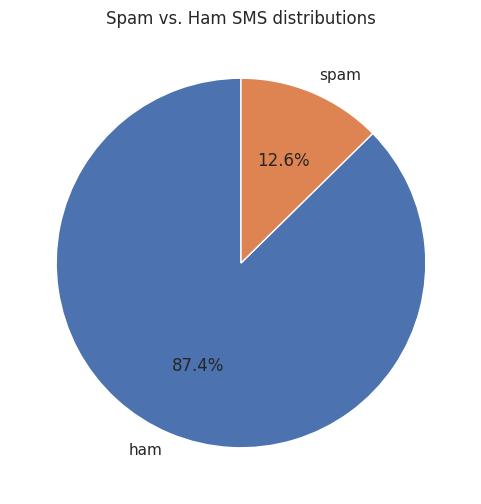

In [ ]:
# Pie chart for spam vs ham distribution
label_counts = df['label'].value_counts()
plt.figure(figsize= (6, 6))
plt.pie(label_counts, labels= label_counts.index, autopct= "%1.1f%%",startangle= 90)
plt.title("Spam vs. Ham SMS distributions")
plt.show()

In [ ]:
# Preview one example message per label
for label in df['label'].unique():
    msg = df.loc[df['label'] == label, 'clean_message'].iloc[0]
    print(f"Label: {label}")
    print(f"Text: {msg}")
    print("-" * 60)

Label: ham
Text: go jurong point , crazy .. available bugis n great world la e buffet ... cine got amore wat ...
------------------------------------------------------------
Label: spam
Text: free entry 2 wkly comp win fa cup final tkts 21st may 2005. text fa 87121 receive entry question ( std txt rate ) & c 's apply 08452810075over18 's
------------------------------------------------------------


Text(0.5, 0, 'Message Length')

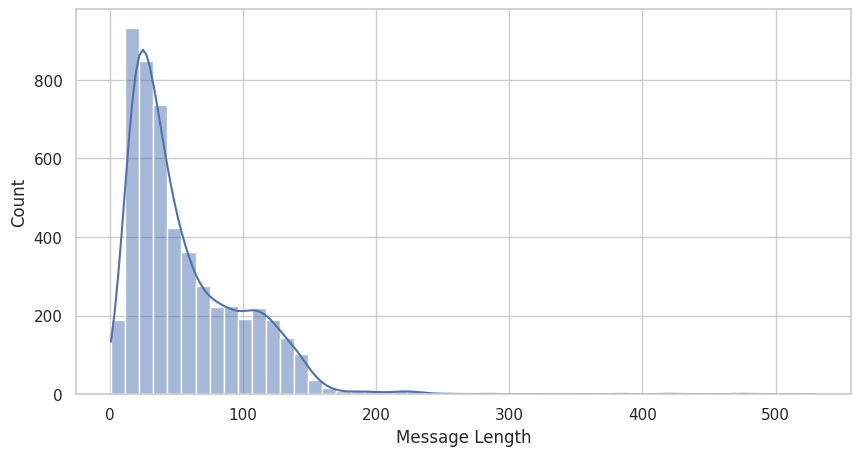

In [ ]:
#Message length histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['clean_message'].apply(len), bins=50, kde=True, ax=ax)
plt.ylabel("Count")
plt.xlabel("Message Length")

Text(0, 0.5, 'Count')

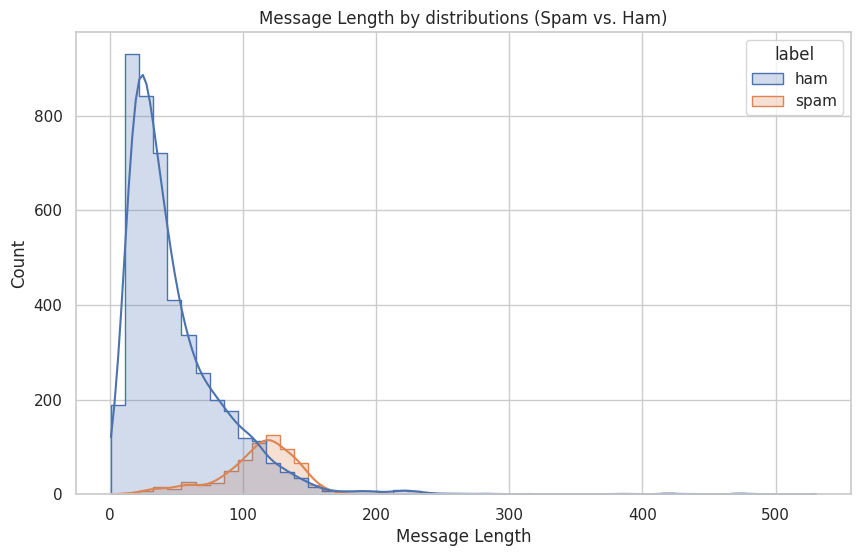

In [ ]:
# Histogram of message lengths by label
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df.assign(text_length=df['clean_message'].apply(len)),
    x='text_length',
    hue='label',
    bins=50,
    kde=True,
    element='step',
    stat='count',
    ax=ax
)

plt.title("Message Length by distributions (Spam vs. Ham)")
plt.xlabel("Message Length")
plt.ylabel("Count")

In [ ]:
# Show shortest and longest messages per label without modifying the main df
for label in df['label'].unique():
    # Filter by label and temporarily assign char_count for sorting
    sub = df[df['label'] == label].assign(char_count=lambda x: x['clean_message'].str.len()).sort_values('char_count')

    print(f"\nLabel = {label}  |  shortest (len={sub.iloc[0]['char_count']}):")
    print(sub.iloc[0]['clean_message'])
    print("-"*60)
    print(f"Label = {label}  |  longest (len={sub.iloc[-1]['char_count']}):")
    print(sub.iloc[-1]['clean_message'][:1000])  # safety cutoff in case extremely long
    print("\n"+ "="*80)


Label = ham  |  shortest (len=1):
?
------------------------------------------------------------
Label = ham  |  longest (len=530):
love start attraction.i feel need every time around me.she first thing comes thoughts.i would start day end her.she every time dream.love every breath name.my life happen around her.my life named her.i would cry her.will give happiness take sorrows.i ready fight anyone her.i love craziest things her.love proove anyone girl beautiful lady whole planet.i always singing praises her.love start making chicken curry end makiing sambar.life beautiful then.will get every morning thank god day me.i would like say lot .. tell later ..


Label = spam  |  shortest (len=13):
2/2 146tf150p
------------------------------------------------------------
Label = spam  |  longest (len=181):
warner village 83118 c colin farrell swat wkend @ warner village & get 1 free med . popcorn ! show message+ticket @ kiosk.valid 4-7/12 . c & c @ kiosk . reply sony 4 mre film offers



(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

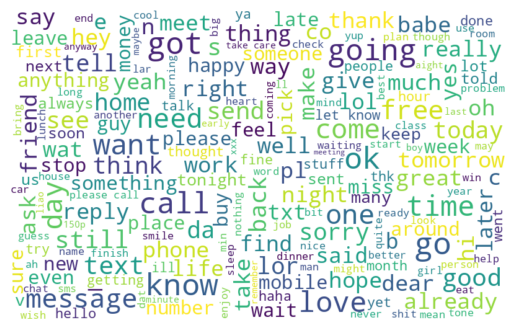

In [ ]:
from wordcloud import WordCloud
text = " ".join(df['clean_message'])
wordcloud = WordCloud(width=800, height=500, max_font_size=50, max_words=200, background_color="white"). generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")


Text(0.5, 1.0, 'Ham Messages Word Cloud')

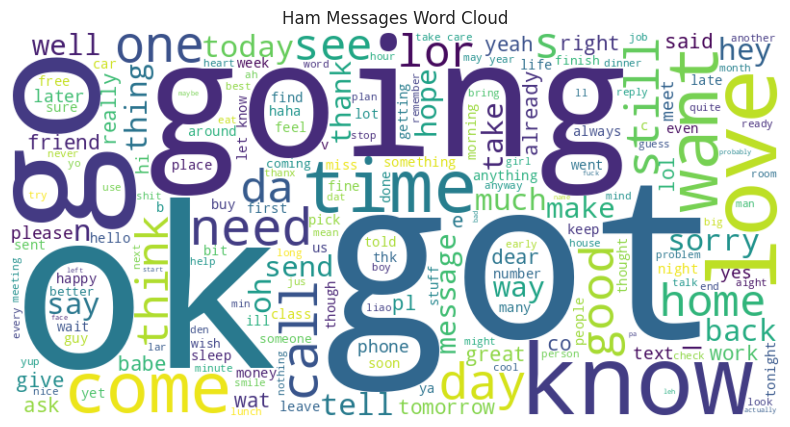

In [ ]:
from wordcloud import WordCloud, STOPWORDS  # <-- Import STOPWORDS here

# Define stop words using the wordcloud defaults
stop_words = STOPWORDS

# Now your original code will run smoothly:
ham_text = " ".join(df[df['label']=='ham']['clean_message'].str.lower())

fig, ax = plt.subplots(figsize=(10, 5))
ham_wc = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(ham_text)
ax.imshow(ham_wc, interpolation='bilinear')
ax.axis('off')
ax.set_title("Ham Messages Word Cloud")

## 5. Label Encoding

In [ ]:
### ham =1, spam=0

df["label"]=df["label"].map({"ham":1,"spam":0})
print("🏷  Label distribution:")
print(df["label"].value_counts())

🏷  Label distribution:
label
1    4516
0     653
Name: count, dtype: int64


## 6. Train-Test Split

In [ ]:
X=df["clean_message"]
y=df["label"]

from sklearn.model_selection import train_test_split
# X_train = training dataset that contains only the reviews, X_test=? y_train=train dataset that contains only label of training reviews, y_test=?
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42, stratify=y)

print(f"📊 Training samples : {len(X_train):,}")
print(f"   Test     samples : {len(X_test):,}")

📊 Training samples : 4,135
   Test     samples : 1,034


## 7. Data Transformation & Padding & Vectorization / Tokenization

In [ ]:
# ── Hyper-parameters (feel free to tune) ────────────────────
VOCAB_SIZE    = 20000    # Only keep the 20 000 most frequent words in the vocabulary
MAX_LEN       = 100      # Every review is trimmed or padded to exactly 100 words
EMBEDDING_DIM = 128      # Each word will be represented by a vector of 128 numbers
OOV_TOKEN     = "<OOV>"  # Placeholder token for words not seen during training

In [ ]:
tokenizer=Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

### token--- seq of int

X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"🔢 Vocabulary size    : {VOCAB_SIZE:,} words")
print(f"   Sequence length   : {MAX_LEN} tokens")
print(f"   X_train_pad shape : {X_train_pad.shape}")
print(f"   X_test_pad  shape : {X_test_pad.shape}")

🔢 Vocabulary size    : 20,000 words
   Sequence length   : 100 tokens
   X_train_pad shape : (4135, 100)
   X_test_pad  shape : (1034, 100)


In [ ]:
TOKENIZER_PATH = "/content/drive/MyDrive/Spam Not Spam Classification RNN/tokenizer.pickle"

# Serialize the fitted tokenizer to disk using pickle
with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)       # Write tokenizer object as binary

print(f"💾 Tokenizer saved → {TOKENIZER_PATH}")

💾 Tokenizer saved → /content/drive/MyDrive/Spam Not Spam Classification RNN/tokenizer.pickle


## 8. Class Imbalance Handling


In [ ]:
# Class weight loss function

from sklearn.utils.class_weight import compute_class_weight

# Calculate weights based on your training labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert arrays into the dictionary required by Keras
cw_dict = dict(zip(np.unique(y_train), class_weights))
print(f"⚖️ Loss penalty weights applied: {cw_dict}")

⚖️ Loss penalty weights applied: {np.int64(0): np.float64(3.960727969348659), np.int64(1): np.float64(0.5722391364517022)}


## 9. Model Architecture

In [ ]:
def build_model(vocab_size: int, embedding_dim: int, max_len: int):
    """
    Construct and compile the Stacked SimpleRNN model based on the attachment.
    Returns the compiled Keras Sequential model.
    """
    model = Sequential(name="SimpleRNN_Spam_Classifier")

    # ── Layer 1: Embedding ────────────────────────────────────
    # Maps each integer token to a dense vector of size embedding_dim.
    # +1 ensures explicit buffer room for index 0 (padding token).
    model.add(Embedding(
        input_dim    = vocab_size + 1,
        output_dim   = embedding_dim,
        name         = "embedding"
    ))

    # ── Layer 2: First SimpleRNN ──────────────────────────────
    # Processes the sequence sequentially step-by-step.
    # return_sequences=True → CRITICAL: Passes the full hidden state sequence
    # to allow the subsequent layer to read temporal relationships.
    model.add(SimpleRNN(
        units            = 64,
        return_sequences = True,
        dropout          = 0.2,
        name             = "simplernn_1"
    ))

    # ── Layer 3: First Dropout ────────────────────────────────
    # Randomly drops 30% of activations to aggressively combat network overfitting.
    model.add(Dropout(0.3, name="dropout_1"))

    # ── Layer 4: Second SimpleRNN ─────────────────────────────
    # Extra depth layer extracting abstract patterns out of downstream features.
    # return_sequences=False → CRITICAL: Drops sequence tracking dimensions,
    # outputting exclusively the final structural hidden state vector.
    model.add(SimpleRNN(
        units            = 32,
        return_sequences = False,
        dropout          = 0.2,
        name             = "simplernn_2"
    ))

    # ── Layer 5: Second Dropout ───────────────────────────────
    model.add(Dropout(0.3, name="dropout_2"))

    # ── Layer 6: Output Dense Layer ───────────────────────────
    # Sigmoid squeezes raw values down to a strict continuous probability scale between 0 and 1.
    model.add(Dense(1, activation="sigmoid", name="output"))

    # ── Compile Configuration ──────────────────────────────────
    model.compile(
        optimizer = "adam",
        loss      = "binary_crossentropy",
        metrics   = ["accuracy"]
    )

    return model

# Build and register layer spatial parameters
model = build_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
model.build((None, MAX_LEN))

# Display structural matrix counts
model.summary()

Model: "SimpleRNN_Spam_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simplernn_1 (SimpleRNN)         │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simplernn_2 (SimpleRNN)         │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,575,617 (9.83 MB)

 Trainable params: 2,575,617 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Model Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Updated path to reflect your SimpleRNN architecture model name
MODEL_PATH = "/content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras"

# ── Callback 1: EarlyStopping ─────────────────────────────────
# If validation loss does not improve for 3 consecutive epochs, stop training.
early_stop = EarlyStopping(
    monitor              = "val_loss",          # Watch validation loss
    patience             = 5,                   # Threshold buffer boundary limit
    restore_best_weights = True,                # Automatically roll back to the optimal epoch weights
    verbose              = 1
)

# ── Callback 2: ModelCheckpoint ───────────────────────────────
# After every epoch, save the model only if val_accuracy is better than before.
checkpoint = ModelCheckpoint(
    filepath       = MODEL_PATH,
    monitor        = "val_accuracy",            # Watch the validation accuracy
    save_best_only = True,                      # Keep the absolute highest performing iteration
    verbose        = 1
)

# ── Training hyper-parameters ────────────────────────────────
EPOCHS     = 20
BATCH_SIZE = 32

print("🚀 Starting SimpleRNN training pipeline …\n")
history = model.fit(
    X_train_pad, y_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.10,
    callbacks        = [early_stop, checkpoint],
    class_weight     = cw_dict,    # <-- CRITICAL EDITS: Applies your balanced loss penalties!
    verbose          = 1
)

print(f"\n✅ Training finished. Best model saved → {MODEL_PATH}")

🚀 Starting SimpleRNN training pipeline …

Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7817 - loss: 0.5168
Epoch 1: val_accuracy improved from None to 0.78502, saving model to /content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.8436 - loss: 0.4202 - val_accuracy: 0.7850 - val_loss: 0.6019
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8943 - loss: 0.3195
Epoch 2: val_accuracy improved from 0.78502 to 0.96135, saving model to /content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8869 - loss: 0.3212 - val_accuracy: 0.9614 - val_loss: 0.1392
Epoch 3/20
117/

In [ ]:
# Evaluate the model on the test dataset
print("🧪 Evaluating model on the test split...")
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=1)

print("\n📊 Final Test Performance Results:")
print(f"   • Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"   • Test Loss     : {test_loss * 100:.2f}%")


🧪 Evaluating model on the test split...
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9768 - loss: 0.0943

📊 Final Test Performance Results:
   • Test Accuracy : 97.68%
   • Test Loss     : 9.43%


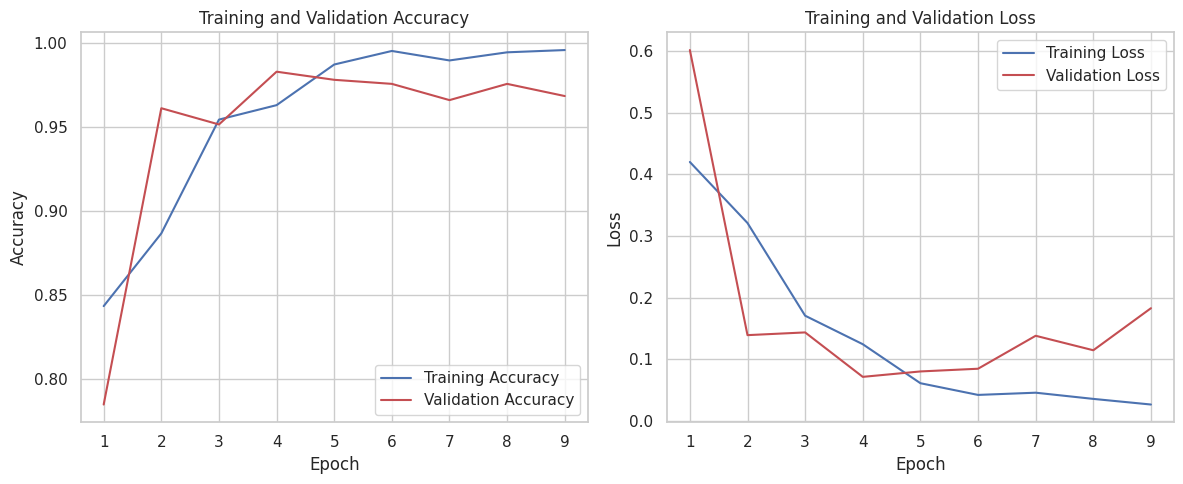

In [ ]:
# Retrieve accuracy and loss values from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

## --- Plot 1: Training and Validation Accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

## --- Plot 2: Training and Validation Loss ---
plt.subplot(1, 2, 2)

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

## 11. Evaluation & Metrics

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

📊 TEXT EVALUATION REPORT (Precision, Recall, F1):
              precision    recall  f1-score   support

    Spam (0)       0.88      0.94      0.91       131
     Ham (1)       0.99      0.98      0.99       903

    accuracy                           0.98      1034
   macro avg       0.94      0.96      0.95      1034
weighted avg       0.98      0.98      0.98      1034



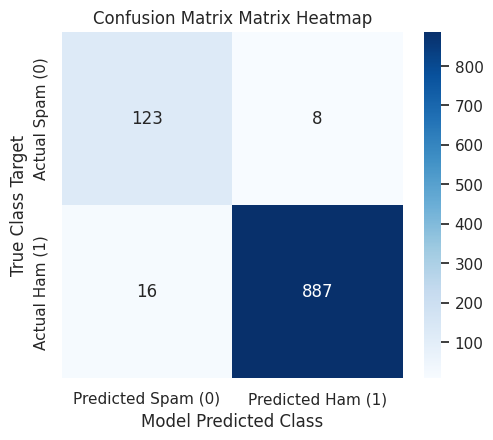

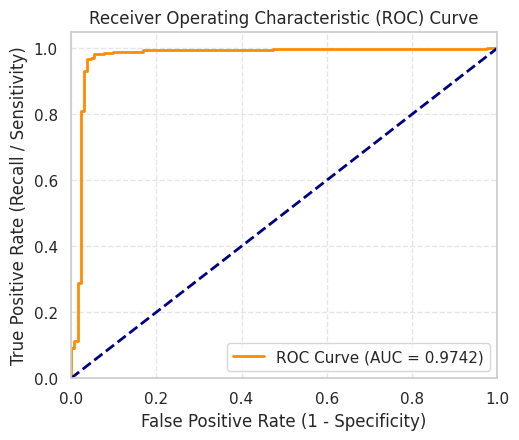

In [ ]:

# 1. Generate model probabilities and binary predictions
# (Remember: ham = 1, spam = 0)
raw_predictions = model.predict(X_test_pad)
preds = (raw_predictions > 0.5).astype("int32").flatten()

# 2. Print Precision, Recall, and F1-Score text report directly to output
print("\n📊 TEXT EVALUATION REPORT (Precision, Recall, F1):")
print(classification_report(y_test, preds, target_names=['Spam (0)', 'Ham (1)']))

# 3. Render Confusion Matrix Heatmap inline
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Spam (0)', 'Predicted Ham (1)'],
    yticklabels=['Actual Spam (0)', 'Actual Ham (1)']
)
plt.title('Confusion Matrix Matrix Heatmap')
plt.ylabel('True Class Target')
plt.xlabel('Model Predicted Class')
plt.show() # <-- Forces notebook inline rendering immediately

# 4. Render ROC Curve and calculate exact AUC Score inline
fpr, tpr, thresholds = roc_curve(y_test, raw_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 50% Random Guess Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() # <-- Forces notebook inline rendering immediately

Ham Detection (Class 1): Exceptional results ($\text{F1-Score} = 0.99$). The model is highly precise ($99\%$) and rarely misclassifies a legitimate email, meaning important communications will almost never accidentally end up blocked in the spam folder.

Spam Detection (Class 0): Very strong recall ($94\%$), showing the model catches the vast majority of junk messages. The precision is slightly lower ($88\%$), indicating that about $12\%$ of the items it flags as spam are actually legitimate emails.

## 12. Model Inference (Load & Predict)

In [ ]:
def predict_lable(clean_message: str,
                      model, tokenizer,
                      max_len: int = MAX_LEN) -> dict:
    """
    Predict the classification of a raw review string.
    Parameters:
    clean_message : str - the raw text to classify
    model : Keras model loaded from disk
    tokenizer : fitted Keras Tokenizer
    max_len : int same MAX_LEN used during training
    Returns:
    dict with keys: clean_text, label, confidence, raw_score
    """

    # — 1. Clean the text using the same 8-step pipeline —
    clean = preprocess_text(clean_message)

    # - 2. Convert words to integer IDs
    seq = tokenizer.texts_to_sequences([clean])

    # — 3. Pad / truncate to fixed length -
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    # — 4. Run through the model -
    score = float(model.predict(padded, verbose=0)[0][0])

    # — 5. Interpret the score —
    # Exact structural mapping: ham = 1 (>= 0.5), spam = 0 (< 0.5)
    label = "Ham (Legitimate)" if score >= 0.5 else "Spam"
    confidence = score if score >= 0.5 else 1.0 - score

    return {
        "clean_text": clean,
        "label": label,
        "confidence": f"{confidence * 100:.1f}%",
        "raw_score": round(score, 4)
    }

print("✅ predict_lable() function defined successfully.")

✅ predict_lable() function defined successfully.


In [ ]:
custom_emails = [
    # 1. Obvious Spam (Classic trigger keywords)
    "CONGRATULATIONS! Your mobile number was selected as the lucky winner of a $5,000 Walmart Gift Card! Text 'WIN' to 88300 immediately to claim your free reward now!",

    # 2. Clear Ham (Casual, personal tone)
    "Hey! Are you free to grab some coffee after work today? Let me know if that time works for you, otherwise we can reschedule for tomorrow morning.",

    # 3. Subtle Spam (Disguised as an official corporate warning)
    "URGENT SECURITY ALERT: Your online banking access has been temporarily locked due to suspicious login attempts. Click here: http://secure-bank-verify.com to unlock your account immediately.",

    # 4. Mixed Content
    "Hey team, just checking in about our budgeting project. Did we settle on how much money we can allocate for the free promotional giveaways next quarter? Let me know your thoughts.",

    # 5. Plain Informational Ham (Professional, zero exclamation points)
    "Dear Student, please find attached the revised schedule for the upcoming oral examinations and project submission guidelines. Ensure your notebook is uploaded by the deadline."
]

# Run the inference tests
print("=" * 65)
print("CUSTOM REVIEW PREDICTIONS")
print("=" * 65)

for i, review in enumerate(custom_emails, 1):
    result = predict_lable(review, model, tokenizer)

    # FIXES: Corrected dictionary keys to match return dict exactly and removed bad string spaces
    print(f"\n[Review {i}]")
    print(f"Input      : {review[:80]}..")
    print(f"Cleaned    : {result['clean_text'][:80]}..")
    print(f"Classifier : {result['label']}")
    print(f"Confidence : {result['confidence']}")
    print(f"Raw Score  : {result['raw_score']}") # Fixed string formatting typo here

print("\n" + "=" * 65)

CUSTOM REVIEW PREDICTIONS

[Review 1]
Input      : CONGRATULATIONS! Your mobile number was selected as the lucky winner of a $5,000..
Cleaned    : congratulations ! mobile number selected lucky winner $ 5,000 walmart gift card ..
Classifier : Spam
Confidence : 98.7%
Raw Score  : 0.0131

[Review 2]
Input      : Hey! Are you free to grab some coffee after work today? Let me know if that time..
Cleaned    : hey ! free grab coffee work today ? let know time works , otherwise reschedule t..
Classifier : Ham (Legitimate)
Confidence : 99.2%
Raw Score  : 0.9921

[Review 3]
Input      : URGENT SECURITY ALERT: Your online banking access has been temporarily locked du..
Cleaned    : urgent security alert : online banking access temporarily locked due suspicious ..
Classifier : Spam
Confidence : 96.0%
Raw Score  : 0.0396

[Review 4]
Input      : Hey team, just checking in about our budgeting project. Did we settle on how muc..
Cleaned    : hey team , checking budgeting project . settle much money 

# 13. Interactive Inferance Test Code

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Optional: Automatically change directory to your project folder
path = "/content/drive/MyDrive//content/drive/MyDrive/Spam Not Spam Classification RNN"
os.chdir(path)
print(f"Current working directory: {os.getcwd()}")

In [ ]:
# =====================================================================
#  Interactive Web UI Test Application (Gradio Interface)
# =====================================================================
# ── Step 1: Force Install Gradio and Text Processing Utilities ───────


!pip install -q gradio contractions emoji beautifulsoup4 nltk scikit-learn

import os
import re
import string
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

import contractions
import emoji
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Setup NLTK dependencies
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
STOP_WORDS = set(stopwords.words("english"))

# Config paths and dimensions
MODEL_PATH = "/content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras"
TOKENIZER_PATH = "/content/drive/MyDrive/Spam Not Spam Classification RNN/tokenizer.pickle"
MAX_LEN = 100

# ── Step 2: Preprocessing Engine ─────────────────────────────────────
def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = text.replace("\u2019", "'").replace("\u2018", "'").replace("\u201c", '"').replace("\u201d", '"')
    text = text.encode("ascii", errors="ignore").decode("ascii")
    text = contractions.fix(text)
    text = text.lower()
    text = emoji.demojize(text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\b\d+\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS]
    return " ".join(tokens)

# ── Step 3: Lazy Load Model Assets into Global State ──────────────────
print("💾 Initializing Saved Model & Tokenizer from Google Drive...")
if os.path.exists(MODEL_PATH) and os.path.exists(TOKENIZER_PATH):
    UI_MODEL = load_model(MODEL_PATH)
    with open(TOKENIZER_PATH, "rb") as f:
        UI_TOKENIZER = pickle.load(f)
    print("✅ Model assets successfully loaded! Launching UI interface...")
else:
    print("❌ Error: Missing saved components. Check paths before launching Gradio.")
    UI_MODEL, UI_TOKENIZER = None, None

# ── Step 4: Core Core Prediction UI Wrapper Function ─────────────────
def gradio_predict_engine(raw_message):
    """
    Interface function that maps a text input string to formatted
    dictionary probabilities for the Gradio label dashboard components.
    """
    if UI_MODEL is None or UI_TOKENIZER is None:
        return {"Error: Model assets missing from Drive": 1.0}

    if not raw_message.strip():
        return {"Please enter text context...": 1.0}

    # Execute backend preprocessing pipeline
    clean = preprocess_text(raw_message)
    seq = UI_TOKENIZER.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    # Run forward pass prediction
    score = float(UI_MODEL.predict(padded, verbose=0)[0][0])

    # Map raw continuous probability scale back into label balances
    # score -> 1.0 means high confidence Ham, score -> 0.0 means high confidence Spam
    ham_prob = score
    spam_prob = 1.0 - score

    return {
        "Ham (Legitimate Message)": ham_prob,
        "Spam (Suspicious Content)": spam_prob
    }

# ── Step 5: Construct Interactive Layout ─────────────────────────────
import gradio as gr

# Setup preset quick-test scenarios for the examiner
example_scenarios = [
    ["CONGRATULATIONS! Your mobile number was selected as the lucky winner of a $5,000 Walmart Gift Card! Text 'WIN' to 88300 immediately to claim your free reward now!"],
    ["Hey! Are you free to grab some coffee after work today? Let me know if that time works for you, otherwise we can reschedule for tomorrow morning."],
    ["URGENT SECURITY ALERT: Your online banking access has been temporarily locked due to suspicious login attempts. Click here: http://secure-bank-verify.com to unlock your account immediately."]
]

app_interface = gr.Interface(
    fn=gradio_predict_engine,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type or paste your SMS/Email message contents here...",
        label="Input Communication Text Content"
    ),
    outputs=gr.Label(num_top_classes=2, label="Classification Analysis Output"),
    examples=example_scenarios,
    title="🛡️ Stacked Spam Detection System",
    description="An interactive playground running your production-trained Stacked Recurrent Neural Network model. Type custom messages below or select an example to evaluate standard context classification.",
    theme="soft"
)

# Launch interface inline directly inside your notebook output block
app_interface.launch(inline=True, share=False)

💾 Initializing Saved Model & Tokenizer from Google Drive...
✅ Model assets successfully loaded! Launching UI interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 14. Explainable AI (XAI) — Post Training

Deep Neural Networks: LIME can be used to interpret predictions from convolutional neural
networks (CNNs) and recurrent neural networks (RNNs).

The purpose of using LIME for the sentimental analysis because it's concentrate into a specific area and fits a linear model predection. LIME works by taking a specific text message, creating slight variations of it (by randomly hiding words), observing how the model's prediction changes, and fitting a simple, interpretable model (like a linear regression) to determine exactly which words contributed most to a "Spam" or "Ham" prediction.

Why not using SHAP: the number of possible word combinations scales exponentially as $2^N$ which computing time huge, where LIME  doesn't care about every mathematical combination. It takes a quick, random sample of perturbed sentences directly around into text instance.

Ref: https://arxiv.org/pdf/2412.00800#page=67.16


In [ ]:
# ====================================================================
# Explainable AI (XAI) Implementation using LIME
# =====================================================================
# ── Step 1: Force Install LIME and Preprocessing Utilities ──────────
!pip install -q lime contractions emoji beautifulsoup4

import os
import re
import string
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

import contractions
import emoji
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Setup NLTK dependencies
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
STOP_WORDS = set(stopwords.words("english"))

# Config paths and dimensions
MODEL_PATH = "/content/drive/MyDrive/Spam Not Spam Classification RNN/simplernn_model_1.keras"
TOKENIZER_PATH = "/content/drive/MyDrive/Spam Not Spam Classification RNN/tokenizer.pickle"
MAX_LEN = 100

# Load assets into state
if os.path.exists(MODEL_PATH) and os.path.exists(TOKENIZER_PATH):
    XAI_MODEL = load_model(MODEL_PATH)
    with open(TOKENIZER_PATH, "rb") as f:
        XAI_TOKENIZER = pickle.load(f)
    print("✅ Model assets successfully loaded for XAI analysis.")
else:
    print("❌ Error: Assets missing. Please verify file paths.")

# ── Step 2: Preprocessing Engine ─────────────────────────────────────
def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = text.replace("\u2019", "'").replace("\u2018", "'").replace("\u201c", '"').replace("\u201d", '"')
    text = text.encode("ascii", errors="ignore").decode("ascii")
    text = contractions.fix(text)
    text = text.lower()
    text = emoji.demojize(text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\b\d+\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS]
    return " ".join(tokens)

# ── Step 3: Define Optimized Pipeline for LIME ───────────────────────
def lime_predict_pipeline(texts_list):
    """
    Highly optimized batch prediction engine to handle perturbations efficiently.
    """
    padded_sequences_list = []
    for text in texts_list:
        clean = preprocess_text(text)
        seq = XAI_TOKENIZER.texts_to_sequences([clean])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")[0]
        padded_sequences_list.append(padded)

    # Batch predict ALL inputs at once instead of looping model.predict
    raw_predictions = XAI_MODEL.predict(np.array(padded_sequences_list), verbose=0)

    probabilities = []
    for pred in raw_predictions:
        ham_prob = float(pred[0])
        spam_prob = 1.0 - ham_prob
        probabilities.append([spam_prob, ham_prob])

    return np.array(probabilities)

# ── Step 4: Initialize LIME Explainer ────────────────────────────────
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=['Spam', 'Ham'])

# ── Step 5: Fast Instance Explanation ────────────────────────────────
# test_message = "URGENT SECURITY ALERT: Your online banking access has been temporarily locked due to suspicious login attempts. Click here: http://secure-bank-verify.com to unlock your account immediately."
test_message = "Skip to contentUsing Gmail with screen readers 4 of 13 Competition Launch: BigQuery AI - Building the Future of DataInbox Kaggle <no-reply@kaggle.com> Unsubscribe W d, Aug 13, 2025, 12:01 AM to me Kaggl Hi Amit Paul,Unlock the hidden value in your data with BigQuery AI.Companies are sitting on piles of data, including chat logs, PDFs, screenshots, and recordings, but they can’t do much with it. It’s often locked away in old systems, stuck in formats no one can touch, or just too messy to deal with. In this hackathon, you’ll build working prototypes that use BigQuery’s Generative AI, Vector Search, and multimodal capabilities to solve data problems. Maybe you’ll dig up related records from a giant archive, pull quick summaries from long reports, or piece together insights from text, images, and audio. And you’ll do all of this while staying in SQL. By combining these AI tools, you can unlock the hidden value in messy or unused data. Total Prizes: $100,000 Final Submission:September 22, 2025 Learn More What you build here could help shape how teams everywhere work with data: structured, unstructured or a mix of both. Good luck, Addison Howard Kaggle Competitions Kaggle, Inc 1600 Amphitheatre Pkwy Mountain View, CA 94043 This email was sent to amitpaul.ac@gmail.com because you indicated that you'd like to receive news and updates about Kaggle. If you don't want to receive these emails in the future, please unsubscribe here. You can also change your preferences on your account's profile page by logging in at kaggle.com."

print("\n🔍 Generating Fast LIME Explanation...")
explanation = explainer.explain_instance(
    text_instance=test_message,
    classifier_fn=lime_predict_pipeline,
    num_features=6,
    labels=(0,),
    num_samples=100 # <-- CRITICAL SPEEDUP: Changes sample count from 5000 to 100 for instant results
)

# Show the results directly in the notebook
explanation.show_in_notebook(text=True)

✅ Model assets successfully loaded for XAI analysis.

🔍 Generating Fast LIME Explanation...
